In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPERIMENT_ROOT = PROJECT_ROOT / "outputs" / "experiments"

EXPERIMENTS = [
    "transformer_baseline",
    "transformer_context_1",
    "transformer_context_3",
    "transformer_context_5",
    "transformer_context_1_speaker",
]

print("Project root:", PROJECT_ROOT)
print("Experiment root:", EXPERIMENT_ROOT)

for name in EXPERIMENTS:
    path = EXPERIMENT_ROOT / name / "predictions.csv"
    assert path.exists(), f"Missing predictions: {path}"

print("All prediction files found.")

Project root: /home/chitta/Projects/emotion-dynamics-nlp
Experiment root: /home/chitta/Projects/emotion-dynamics-nlp/outputs/experiments
All prediction files found.


In [2]:


MELD_TEST = PROJECT_ROOT / "data" / "raw" / "meld" / "test_sent_emo.csv"

assert MELD_TEST.exists(), f"MELD test file not found: {MELD_TEST}"

test_df = pd.read_csv(MELD_TEST)

print("MELD test shape:", test_df.shape)
print("Columns:", list(test_df.columns))

MELD test shape: (2610, 11)
Columns: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']


In [3]:
predictions = {}

for name in EXPERIMENTS:
    path = EXPERIMENT_ROOT / name / "predictions.csv"
    predictions[name] = pd.read_csv(path)

    print(
        name,
        predictions[name].shape,
        list(predictions[name].columns),
    )

transformer_baseline (2610, 24) ['Sr No.', 'text', 'speaker', 'emotion', 'Sentiment', 'dialogue_id', 'utterance_id', 'Season', 'Episode', 'StartTime', 'EndTime', 'model_text', 'true_emotion', 'label_id', 'predicted_id', 'predicted_emotion', 'correct', 'prob_anger', 'prob_disgust', 'prob_fear', 'prob_joy', 'prob_neutral', 'prob_sadness', 'prob_surprise']
transformer_context_1 (2328, 19) ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context', 'model_text', 'true_emotion', 'label_id', 'predicted_id', 'predicted_emotion', 'correct', 'prob_anger', 'prob_disgust', 'prob_fear', 'prob_joy', 'prob_neutral', 'prob_sadness', 'prob_surprise']
transformer_context_3 (1807, 19) ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context', 'model_text', 'true_emotion', 'label_id', 'predicted_id', 'predicted_emotion', 'correct', 'prob_anger', 'prob_disgust', 'prob_fear', 'prob_joy', 'prob_neutral', 'prob_sadness', 'prob_surprise']
transformer_context_5 (1354, 19) ['dialogue_

In [4]:
# Align predictions by MELD dialogue + utterance identity

KEYS = ["dialogue_id", "utterance_id"]

for name, df in predictions.items():
    duplicates = df.duplicated(KEYS).sum()
    assert duplicates == 0, (
        f"{name} contains {duplicates} duplicate dialogue/utterance keys."
    )

print("Duplicate-key checks passed.")


# Keep only the columns needed for cross-model comparison.
def comparison_frame(df, model_name):
    return df[
        KEYS + [
            "text",
            "speaker",
            "true_emotion",
            "predicted_emotion",
            "correct",
        ]
    ].rename(
        columns={
            "true_emotion": f"true_{model_name}",
            "predicted_emotion": f"pred_{model_name}",
            "correct": f"correct_{model_name}",
        }
    )


baseline_cmp = comparison_frame(
    predictions["transformer_baseline"],
    "baseline",
)

context1_cmp = comparison_frame(
    predictions["transformer_context_1"],
    "context1",
)

speaker1_cmp = comparison_frame(
    predictions["transformer_context_1_speaker"],
    "speaker1",
)


matched = baseline_cmp.merge(
    context1_cmp,
    on=KEYS,
    how="inner",
    suffixes=("", "_context"),
).merge(
    speaker1_cmp,
    on=KEYS,
    how="inner",
    suffixes=("", "_speaker"),
)

print("Matched baseline / Context-1 / Context-1+Speaker examples:", len(matched))

# All models must agree on the ground-truth emotion.
assert (
    matched["true_baseline"]
    == matched["true_context1"]
).all()

assert (
    matched["true_baseline"]
    == matched["true_speaker1"]
).all()

print("Ground-truth alignment passed.")

Duplicate-key checks passed.
Matched baseline / Context-1 / Context-1+Speaker examples: 2328
Ground-truth alignment passed.


In [5]:
# Baseline vs Context-1: error transition analysis

matched["baseline_to_context1"] = "both_wrong"

matched.loc[
    matched["correct_baseline"] & matched["correct_context1"],
    "baseline_to_context1"
] = "both_correct"

matched.loc[
    matched["correct_baseline"] & ~matched["correct_context1"],
    "baseline_to_context1"
] = "baseline_only"

matched.loc[
    ~matched["correct_baseline"] & matched["correct_context1"],
    "baseline_to_context1"
] = "context1_only"

transition_counts = (
    matched["baseline_to_context1"]
    .value_counts()
    .reindex(
        [
            "both_correct",
            "baseline_only",
            "context1_only",
            "both_wrong",
        ],
        fill_value=0,
    )
)

transition_table = pd.DataFrame({
    "count": transition_counts,
    "percent": (
        transition_counts / len(matched) * 100
    ).round(2),
})

display(transition_table)

,count,percent
baseline_to_context1,,
both_correct,1155,49.61
baseline_only,229,9.84
context1_only,259,11.13
both_wrong,685,29.42


In [6]:
matched_accuracy = pd.DataFrame({
    "model": [
        "Baseline",
        "Context-1",
        "Context-1 + Speaker",
    ],
    "accuracy": [
        matched["correct_baseline"].mean(),
        matched["correct_context1"].mean(),
        matched["correct_speaker1"].mean(),
    ],
})

matched_accuracy["accuracy"] = (
    matched_accuracy["accuracy"] * 100
).round(2)

display(matched_accuracy)

,model,accuracy
0,Baseline,59.45
1,Context-1,60.74
2,Context-1 + Speaker,61.94


In [7]:
# # Context-1 vs Context-1 + Speaker:
# error transition analysis

matched["context1_to_speaker1"] = "both_wrong"

matched.loc[
    matched["correct_context1"] & matched["correct_speaker1"],
    "context1_to_speaker1"
] = "both_correct"

matched.loc[
    matched["correct_context1"] & ~matched["correct_speaker1"],
    "context1_to_speaker1"
] = "context1_only"

matched.loc[
    ~matched["correct_context1"] & matched["correct_speaker1"],
    "context1_to_speaker1"
] = "speaker1_only"

transition_counts_speaker = (
    matched["context1_to_speaker1"]
    .value_counts()
    .reindex(
        [
            "both_correct",
            "context1_only",
            "speaker1_only",
            "both_wrong",
        ],
        fill_value=0,
    )
)

transition_table_speaker = pd.DataFrame({
    "count": transition_counts_speaker,
    "percent": (
        transition_counts_speaker / len(matched) * 100
    ).round(2),
})

display(transition_table_speaker)

,count,percent
context1_to_speaker1,,
both_correct,1253,53.82
context1_only,161,6.92
speaker1_only,189,8.12
both_wrong,725,31.14


In [8]:
# Per-emotion accuracy on the matched 2,328 utterances

emotions = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise",
]

per_class_rows = []

for emotion in emotions:
    subset = matched[matched["true_baseline"] == emotion]

    per_class_rows.append({
        "emotion": emotion,
        "n": len(subset),
        "baseline_accuracy": subset["correct_baseline"].mean() * 100,
        "context1_accuracy": subset["correct_context1"].mean() * 100,
        "speaker1_accuracy": subset["correct_speaker1"].mean() * 100,
    })

per_class = pd.DataFrame(per_class_rows)

per_class["context1_delta"] = (
    per_class["context1_accuracy"]
    - per_class["baseline_accuracy"]
)

per_class["speaker1_delta"] = (
    per_class["speaker1_accuracy"]
    - per_class["context1_accuracy"]
)

per_class = per_class.round(2)

display(per_class)

,emotion,n,baseline_accuracy,context1_accuracy,speaker1_accuracy,context1_delta,speaker1_delta
0,anger,307,36.81,30.94,31.60,-5.86,0.65
1,disgust,63,20.63,14.29,11.11,-6.35,-3.17
2,fear,44,25.00,6.82,11.36,-18.18,4.55
3,joy,358,58.66,54.47,58.38,-4.19,3.91
4,neutral,1116,73.57,83.33,82.35,9.77,-0.99
5,sadness,187,33.16,16.04,20.32,-17.11,4.28
6,surprise,253,60.87,60.08,66.01,-0.79,5.93


/tmp/ipykernel_1028278/3579553096.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


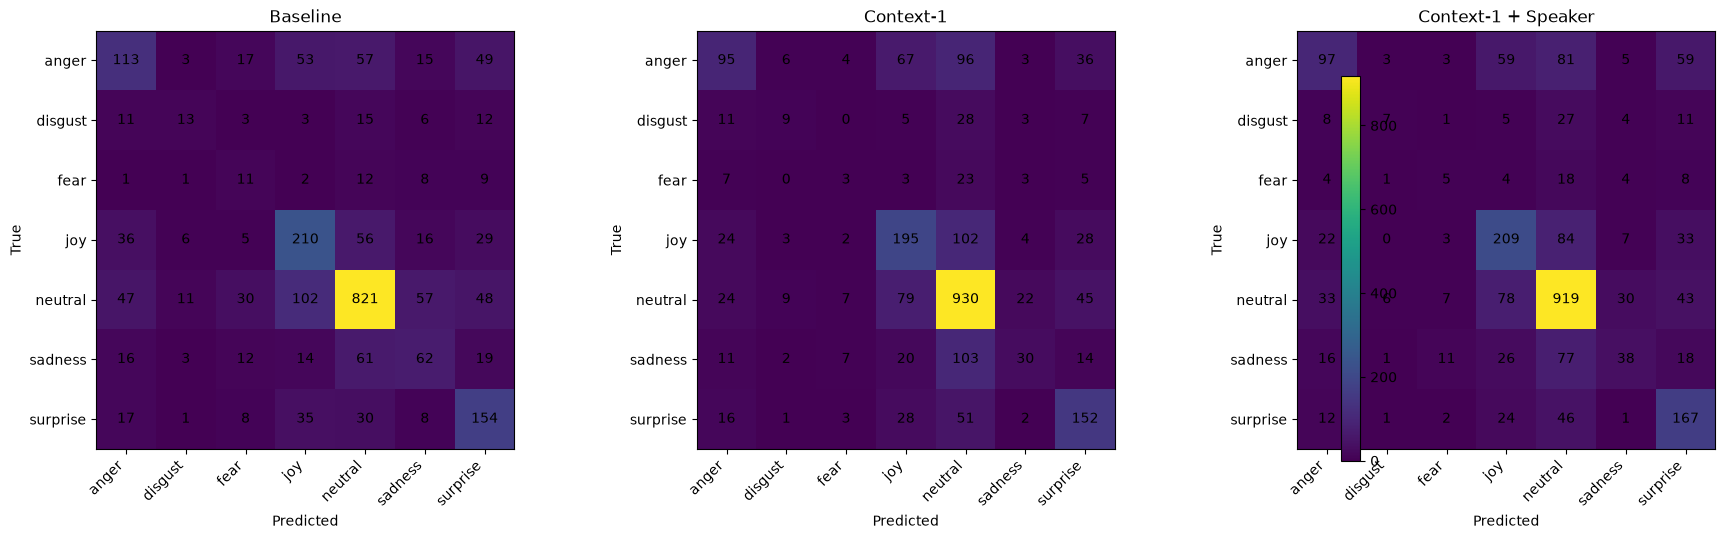

In [9]:
from sklearn.metrics import confusion_matrix

# Matched confusion matrices: same 2,328 utterances

labels = emotions

cm_baseline = confusion_matrix(
    matched["true_baseline"],
    matched["pred_baseline"],
    labels=labels,
)

cm_context1 = confusion_matrix(
    matched["true_baseline"],
    matched["pred_context1"],
    labels=labels,
)

cm_speaker1 = confusion_matrix(
    matched["true_baseline"],
    matched["pred_speaker1"],
    labels=labels,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms = [
    (cm_baseline, "Baseline"),
    (cm_context1, "Context-1"),
    (cm_speaker1, "Context-1 + Speaker"),
]

for ax, (cm, title) in zip(axes, cms):
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
            )

fig.colorbar(im, ax=axes)
plt.tight_layout()
plt.show()

In [10]:
# Identify the largest confusion shifts:
# Baseline -> Context-1

shift_rows = []

for true_emotion in emotions:
    for predicted_emotion in emotions:

        baseline_count = cm_baseline[
            emotions.index(true_emotion),
            emotions.index(predicted_emotion)
        ]

        context_count = cm_context1[
            emotions.index(true_emotion),
            emotions.index(predicted_emotion)
        ]

        shift_rows.append({
            "true_emotion": true_emotion,
            "predicted_emotion": predicted_emotion,
            "baseline": baseline_count,
            "context1": context_count,
            "change": context_count - baseline_count,
        })

confusion_shifts = pd.DataFrame(shift_rows)

# Exclude unchanged cells and sort by largest absolute change.
confusion_shifts["abs_change"] = (
    confusion_shifts["change"].abs()
)

confusion_shifts = (
    confusion_shifts[
        confusion_shifts["change"] != 0
    ]
    .sort_values("abs_change", ascending=False)
    .drop(columns="abs_change")
    .reset_index(drop=True)
)

display(confusion_shifts.head(20))

,true_emotion,predicted_emotion,baseline,context1,change
0,neutral,neutral,821,930,109
1,joy,neutral,56,102,46
2,sadness,neutral,61,103,42
3,anger,neutral,57,96,39
4,neutral,sadness,57,22,-35
5,sadness,sadness,62,30,-32
6,neutral,anger,47,24,-23
7,neutral,fear,30,7,-23
8,neutral,joy,102,79,-23
9,surprise,neutral,30,51,21


In [11]:
# Examples where Context-1 RESCUED a baseline error

rescued = matched[
    (~matched["correct_baseline"]) &
    (matched["correct_context1"])
].copy()

print("Rescued examples:", len(rescued))

display(
    rescued[
        [
            "dialogue_id",
            "utterance_id",
            "speaker",
            "text",
            "true_baseline",
            "pred_baseline",
            "pred_context1",
        ]
    ].head(20)
)

Rescued examples: 259


,dialogue_id,utterance_id,speaker,text,true_baseline,pred_baseline,pred_context1
4,1,3,Joey,"Push 'em out, push 'em out, way out!",joy,fear,joy
7,1,6,Joey,Push!,joy,anger,joy
30,4,6,Monica,"Oh wait, Joey, you can’t go like that! You stink!",disgust,surprise,disgust
31,4,7,Joey,"Look, I know I feel asleep before I could show...",anger,sadness,anger
32,4,8,Joey,"They’re just ten blocks away, if I run, I can ...",neutral,fear,neutral
36,5,4,Marjorie,"No, please.",neutral,sadness,neutral
44,7,2,Joey,"And it’s not fake, it’s totally brutal.",neutral,anger,neutral
50,7,8,Joey,"What? My hands are totally clean, I just gave ...",neutral,surprise,neutral
51,8,1,Chandler,"Well, that makes me feel so good.",joy,neutral,joy
64,9,8,Joey,"Oh, how bad is it?",sadness,neutral,sadness


In [12]:
# Examples where Context-1 BROKE a baseline correct prediction

broken = matched[
    (matched["correct_baseline"]) &
    (~matched["correct_context1"])
].copy()

print("Broken examples:", len(broken))

display(
    broken[
        [
            "dialogue_id",
            "utterance_id",
            "speaker",
            "text",
            "true_baseline",
            "pred_baseline",
            "pred_context1",
        ]
    ].head(20)
)

Broken examples: 229


,dialogue_id,utterance_id,speaker,text,true_baseline,pred_baseline,pred_context1
0,0,1,Rachel,Oh. That’s so Monica can keep track. That way ...,anger,anger,neutral
3,1,2,Joey,"Push 'em out, push 'em out, harder, harder.",joy,joy,neutral
12,2,4,Rachel,"Okay, y'know what? There is no more left, left!",anger,anger,joy
20,3,2,Steve,Howard's the,neutral,neutral,joy
26,4,2,Phoebe,It kicked! I think the baby kicked!,surprise,surprise,anger
49,7,7,Ross,"Huh, what’s fish hooking... Thanks man, that...",neutral,neutral,disgust
65,9,9,Phoebe,"Oh, it’s bad. It’s really bad. The only thing ...",sadness,sadness,neutral
69,9,13,Rachel,Fine! I’m sorry for your loss!,anger,anger,joy
73,9,17,Chandler,Have you figured out what started the fire Mr....,neutral,neutral,surprise
77,11,1,Rachel,I mean there’s no way Joey’s gonna make it in ...,fear,fear,neutral


In [16]:
def show_error_examples(examples_df, title, n=10, context_turns=2):
    rows = []

    for _, example in examples_df.head(n).iterrows():
        dialogue_id = example["dialogue_id"]
        utterance_id = example["utterance_id"]

        dialogue = (
            test_df[test_df["Dialogue_ID"] == dialogue_id]
            .sort_values("Utterance_ID")
            .reset_index(drop=True)
        )

        target_positions = dialogue.index[
            dialogue["Utterance_ID"] == utterance_id
        ]

        if len(target_positions) == 0:
            continue

        target_pos = target_positions[0]
        start = max(0, target_pos - context_turns)

        context = dialogue.iloc[start:target_pos + 1]

        conversation = "\n".join(
            f'{int(row["Utterance_ID"])} | {row["Speaker"]}: {row["Utterance"]}'
            for _, row in context.iterrows()
        )

        rows.append({
            "dialogue_id": dialogue_id,
            "utterance_id": utterance_id,
            "conversation": conversation,
            "true": example["true_baseline"],
            "baseline": example["pred_baseline"],
            "context1": example["pred_context1"],
        })

    result = pd.DataFrame(rows)

    print(title)
    display(result)
    return result

In [17]:
rescued_examples = show_error_examples(
    rescued,
    "Context-1 rescued baseline errors",
    n=10,
    context_turns=2,
)

broken_examples = show_error_examples(
    broken,
    "Context-1 broke baseline predictions",
    n=10,
    context_turns=2,
)

Context-1 rescued baseline errors


,dialogue_id,utterance_id,conversation,true,baseline,context1
0,1,3,"1 | Joey: Push!\n2 | Joey: Push 'em out, push ...",joy,fear,joy
1,1,6,"4 | Joey: Let's get that ball and really move,...",joy,anger,joy
2,4,6,"4 | Phoebe: Oh no wait, oh no, the elastic on ...",disgust,surprise,disgust
3,4,7,5 | Joey: Oh my God! I overslept! I was suppos...,anger,sadness,anger
4,4,8,"6 | Monica: Oh wait, Joey, you can’t go like t...",neutral,fear,neutral
5,5,4,2 | Marjorie: Hi.\n3 | Chandler: You mind if I...,neutral,sadness,neutral
6,7,2,"0 | Monica: Yeah, but without the costumes.\n1...",neutral,anger,neutral
7,7,8,6 | Monica: What’s fish hooking?\n7 | Ross: Hu...,neutral,surprise,neutral
8,8,1,"0 | Jade: Oh, Bob, he was nothing compared to ...",joy,neutral,joy
9,9,8,6 | Fireman #1: Excuse me?\n7 | Monica: Joey! ...,sadness,neutral,sadness


Context-1 broke baseline predictions


,dialogue_id,utterance_id,conversation,true,baseline,context1
0,0,1,0 | Mark: Why do all you’re coffee mugs have n...,anger,anger,neutral
1,1,2,"0 | Joey: Come on, Lydia, you can do it.\n1 | ...",joy,joy,neutral
2,2,4,"2 | Ross: Uhh, yes I did but there isn't. Okay...",anger,anger,joy
3,3,2,"0 | Steve: Oh, okay, I get it.\n1 | Ross: No w...",neutral,neutral,joy
4,4,2,0 | Phoebe: Ohh!\n1 | Monica: What?\n2 | Phoeb...,surprise,surprise,anger
5,7,7,"5 | Ross: Yeah, anything goes, except ah, eye ...",neutral,neutral,disgust
6,9,9,7 | Monica: Joey! He’s working! You would loo...,sadness,sadness,neutral
7,9,13,11 | Rachel: Everything’s ruined. My bed. My c...,anger,anger,joy
8,9,17,"15 | Rachel: Wow! Oh-okay, look pal, I am\n16 ...",neutral,neutral,surprise
9,11,1,"0 | Rachel: Well Phoebe, we gotta do something...",fear,fear,neutral


In [18]:
# Save the qualitative examples used in Week 6 analysis

qualitative_examples = pd.concat(
    [
        rescued_examples.assign(category="rescued"),
        broken_examples.assign(category="broken"),
    ],
    ignore_index=True,
)

output_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "week6_qualitative_examples.csv"
)

output_path.parent.mkdir(parents=True, exist_ok=True)

qualitative_examples.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Examples:", len(qualitative_examples))

Saved: /home/chitta/Projects/emotion-dynamics-nlp/outputs/tables/week6_qualitative_examples.csv
Examples: 20
